# 00 — Comprensión de los datos crudos

**Objetivo:** entender qué contienen los JSON exportados de los collares Tractive (`data/<perro>/`) antes de analizarlos, y justificar cómo `src/utils/data_loader.py` los convierte en tablas.

No es el EDA: aquí no se comparan perros ni se contrastan hipótesis.

> Este notebook lee los exports originales, que **no se publican** porque algunos ficheros contienen la ubicación de la casa. `main.ipynb` solo usa los datasets derivados de `src/data_sample`.

In [1]:
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../utils")   # data_loader.py está en src/utils
import data_loader

CRUDOS = "../../../data"   # exports originales, fuera del repositorio
PERROS = ["cherry", "coco", "kiwi", "plum"]
FICHEROS = ["activity_data", "barks", "resting_heart_rates", "resting_respiratory_rates",
            "hardware_reports", "network_reports", "server_commands", "wifi_reports",
            "position_reports", "geofences", "pet_zones", "power_saving_zones"]


def leer(perro, fichero):
    with open(f"{CRUDOS}/{perro}/{fichero}.json") as f:
        return json.load(f)

## 1. Inventario

Cada perro tiene los mismos 12 ficheros, que se agrupan en tres familias:

- **Comportamiento**, las que interesan: `activity_data`, `barks`, `resting_heart_rates` y `resting_respiratory_rates`.
- **Estado del collar**: `hardware_reports` (batería y temperatura), `network_reports`, `server_commands` y `wifi_reports`.
- **Localización** ⚠️: `position_reports`, `geofences`, `pet_zones` y `power_saving_zones`. Contienen coordenadas de la casa, así que **no se usan en el análisis ni se publican**.

Número de registros de cada fichero:

In [2]:
registros = {}
for perro in PERROS:
    registros[perro] = {}
    for fichero in FICHEROS:
        contenido = leer(perro, fichero)
        registros[perro][fichero] = len(contenido) if isinstance(contenido, list) else 1
pd.DataFrame(registros)

,cherry,coco,kiwi,plum
activity_data,200,169,328,201
barks,200,169,0,200
resting_heart_rates,200,169,325,201
resting_respiratory_rates,200,169,325,201
hardware_reports,3092,4950,9689,3756
network_reports,776,2000,2187,1164
server_commands,10,14,33,2
wifi_reports,1,1,1,1
position_reports,2261,4114,7575,3567
geofences,1,1,1,1


**Primer hallazgo: `barks` de kiwi está vacío.** Su collar es de otro modelo y no tiene sensor de ladridos. Sus nulos de ladridos serán estructurales (no hay nada que rellenar) y kiwi quedará fuera de los análisis de ladridos.

También se ve que la longitud del histórico cambia mucho de un perro a otro.

## 2. Cómo está guardada cada señal

Los campos de un registro de ejemplo de cada fichero, sin los identificadores del collar ni de los registros:

In [3]:
for fichero in ["activity_data", "barks", "resting_heart_rates", "hardware_reports"]:
    print(f"--- {fichero} ---")
    for campo, valor in leer("cherry", fichero)[0].items():
        if "id" not in campo.lower():   # los identificadores no se muestran
            print(f"  {campo}: {json.dumps(valor)[:90]}")
    print()

--- activity_data ---


  gmtTime: 1771718400000
  gmtOffset: 3600000
  activityCategories: [[69335, null], [6, -1], [2, -1], [3, 1], [2, 0], [75, 6], [1, -1], [2, -1], [1, 6], [15, 

--- barks ---
  local_date: "2026-02-22"
  periods: [null, null, null, null, null, null, null, null, null, null, null, null, null, null, null,
  period_length_in_millis: 1800000

--- resting_heart_rates ---
  local_date: "2026-02-22"
  records: [{"local_time": "19:35:53+01:00", "samples": [60]}, {"local_time": "19:38:48+01:00", "samp

--- hardware_reports ---
  battery_level: 100
  battery_state: "FULL"
  battery_voltage: 4.186
  charger_connected: false
  charger_enabled: true
  estimated_battery_capacity: 100
  source: "TRACKER"
  system_shutdown_type: "NOT_SET"
  system_startup_type: "TRIGGERED_BY_USER"
  temperature: 20
  time: "2026-02-22T18:15:35+00:00"
  time_rcvd: "2026-02-22T18:16:05+00:00"



| Fichero | Cómo está guardado | Cómo se pasa a tabla |
|---|---|---|
| `activity_data` | Pares `[duración en segundos, categoría]` que recorren el día seguidos | Minutos de cada categoría por día y por hora |
| `barks` | 48 franjas de 30 minutos; `null` significa sin ladridos | Total del día y una fila por franja |
| `resting_*_rates` | Muestras sueltas a lo largo del día | Media, mínimo, máximo y nº de muestras por día |
| `hardware_reports` | Informes del collar con su temperatura | Temperatura media y máxima por día |

## 3. Los tramos de actividad cubren el día entero

Si los pares `[duración, categoría]` recorren el día completo, sus duraciones deben sumar 86.400 segundos (24 horas) en todos los días.

In [4]:
actividad = {}
for perro in PERROS:
    actividad[perro] = leer(perro, "activity_data")
    duraciones = [sum(tramo[0] for tramo in dia["activityCategories"]) for dia in actividad[perro]]
    print(f"{perro}: {len(duraciones)} días | suma mínima {min(duraciones)} s | suma máxima {max(duraciones)} s")

cherry: 200 días | suma mínima 86400 s | suma máxima 86400 s


coco: 169 días | suma mínima 86400 s | suma máxima 86400 s


kiwi: 328 días | suma mínima 86400 s | suma máxima 86400 s


plum: 201 días | suma mínima 86400 s | suma máxima 86400 s


✅ Todos los días suman exactamente 86.400 segundos. Reparto del tiempo por categoría, en %:

In [5]:
reparto = {}
for perro in PERROS:
    segundos = {}
    for dia in actividad[perro]:
        for duracion, categoria in dia["activityCategories"]:
            segundos[str(categoria)] = segundos.get(str(categoria), 0) + duracion
    total = sum(segundos.values())
    reparto[perro] = {}
    for categoria in segundos:
        reparto[perro][categoria] = round(100 * segundos[categoria] / total, 1)
pd.DataFrame(reparto).fillna(0)

,cherry,coco,kiwi,plum
None,0.5,0.7,1.2,1.5
-1,22.8,22.5,22.4,23.6
1,6.8,8.8,8.9,7.2
0,3.4,2.1,7.9,3.3
6,65.6,64.6,58.2,62.9
7,0.8,1.2,1.3,1.4
5,0.0,0.1,0.0,0.0


Las mismas categorías aparecen en los cuatro collares con pesos parecidos: la codificación es la misma.

> ⚠️ Esta tabla **no sirve para comparar el comportamiento** de los perros: mezcla periodos distintos (kiwi incluye el invierno) y cuenta el tiempo sin datos. Esa comparación se hace en `main.ipynb`.

## 4. ¿Qué significa cada categoría?

El export no documenta las categorías (-1, 0, 1, 5, 6, 7 y `None`). Para interpretarlas se mira a qué hora del día aparece cada una: la que domine de madrugada debería ser el sueño.

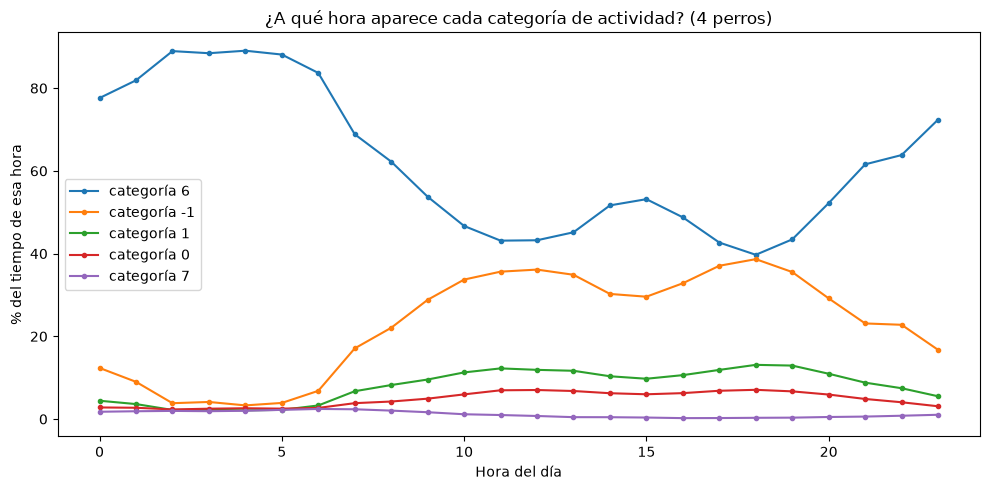

Categoría 6 a las 4:00: 89.1 %


In [6]:
# segundos de cada categoría en cada hora, sumando los cuatro perros
por_hora = []
for _ in range(24):
    por_hora.append({})

for perro in PERROS:
    for dia in actividad[perro]:
        inicio = 0
        for duracion, categoria in dia["activityCategories"]:
            fin = inicio + duracion
            for hora in range(inicio // 3600, min(fin // 3600 + 1, 24)):
                solape = min(fin, (hora + 1) * 3600) - max(inicio, hora * 3600)
                if solape > 0:
                    por_hora[hora][str(categoria)] = por_hora[hora].get(str(categoria), 0) + solape
            inicio = fin

filas = []
for hora in range(24):
    total = sum(por_hora[hora].values())
    fila = {}
    for categoria in por_hora[hora]:
        fila[categoria] = 100 * por_hora[hora][categoria] / total
    filas.append(fila)
porcentajes = pd.DataFrame(filas).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
for categoria in ["6", "-1", "1", "0", "7"]:
    ax.plot(porcentajes.index, porcentajes[categoria], marker="o", markersize=3,
            label=f"categoría {categoria}")
ax.set_xlabel("Hora del día")
ax.set_ylabel("% del tiempo de esa hora")
ax.set_title("¿A qué hora aparece cada categoría de actividad? (4 perros)")
ax.legend()
plt.tight_layout()
plt.savefig("../img/00_categorias_por_hora.png", dpi=150)
plt.show()

print("Categoría 6 a las 4:00:", round(porcentajes.loc[4, "6"], 1), "%")

| Categoría | Interpretación | Por qué |
|---|---|---|
| 6 | **Reposo o sueño** | Domina la madrugada y baja durante el día |
| -1 y `None` | **Sin datos** | Crece durante el día (carga del collar, falta de cobertura) |
| 1 | **Activo** | Aparece de día |
| 0 | **Calma** (despierto y quieto) | Aparece de día, junto a la 1 |
| 7 | **Intenso** | Poco frecuente |
| 5 | **Otros** | Casi inexistente |

Es una interpretación deducida de los datos, no documentación oficial del fabricante.

### 4.1 Una salvedad sobre la categoría 7

Durante el análisis aparecieron días con muchas horas de categoría 7 y, sin embargo, la frecuencia cardíaca en reposo normal. Para entenderlo se busca, en cada día, el tramo continuo más largo de esa categoría:

In [7]:
filas = []
for perro in PERROS:
    for dia in actividad[perro]:
        duraciones_7 = [duracion for duracion, categoria in dia["activityCategories"] if categoria == 7]
        filas.append({"perro": perro,
                      "fecha": data_loader.fecha_local(dia),
                      "n_tramos": len(dia["activityCategories"]),
                      "tramo_7_mas_largo_h": max(duraciones_7) / 3600 if duraciones_7 else 0,
                      "total_7_h": sum(duraciones_7) / 3600})
tramos_7 = pd.DataFrame(filas)

for horas in [1, 2, 4]:
    print(f"Días con un tramo de categoría 7 de más de {horas} h:",
          (tramos_7["tramo_7_mas_largo_h"] > horas).sum(), "de", len(tramos_7))
print("Tramo más largo:", round(tramos_7["tramo_7_mas_largo_h"].max(), 2), "h")

con_bloque = tramos_7["tramo_7_mas_largo_h"] > 2
print("\nCambios de categoría por día (mediana): días con un bloque de más de 2 h",
      tramos_7[con_bloque]["n_tramos"].median(), "| resto de días", tramos_7[~con_bloque]["n_tramos"].median())

Días con un tramo de categoría 7 de más de 1 h: 44 de 898
Días con un tramo de categoría 7 de más de 2 h: 34 de 898
Días con un tramo de categoría 7 de más de 4 h: 23 de 898
Tramo más largo: 12.99 h

Cambios de categoría por día (mediana): días con un bloque de más de 2 h 6463.0 | resto de días 7929.0


Hay días con **un único tramo de categoría 7 de casi 13 horas**, mientras que en un día normal la actividad cambia de categoría miles de veces. ¿Acompaña la frecuencia cardíaca?

In [8]:
vitales = []
for perro in PERROS:
    vitales.append(data_loader.vitales_diarios(CRUDOS, perro, "resting_heart_rates", "fc"))
vitales = pd.concat(vitales).merge(tramos_7, on=["perro", "fecha"])
vitales["con_bloque"] = vitales["tramo_7_mas_largo_h"] > 2

print("FC media en reposo (mediana):")
print(vitales.groupby("con_bloque")["fc_media"].median().round(1))

FC media en reposo (mediana):
con_bloque
False    58.7
True     60.4
Name: fc_media, dtype: float64


Apenas un par de latidos más: horas de ejercicio intenso dejarían una huella mucho mayor. ¿A qué hora ocurren esos bloques?

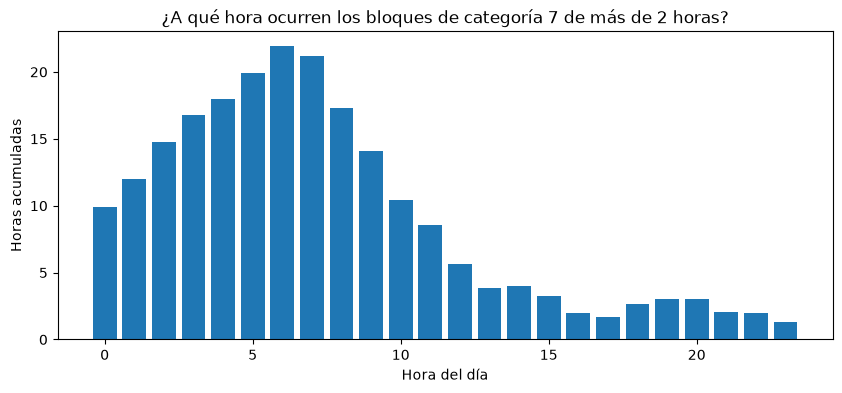

In [9]:
horas_de_bloque = [0] * 24
for perro in PERROS:
    for dia in actividad[perro]:
        inicio = 0
        for duracion, categoria in dia["activityCategories"]:
            fin = inicio + duracion
            if categoria == 7 and duracion > 2 * 3600:
                for hora in range(inicio // 3600, min(fin // 3600 + 1, 24)):
                    solape = min(fin, (hora + 1) * 3600) - max(inicio, hora * 3600)
                    if solape > 0:
                        horas_de_bloque[hora] += solape / 3600
            inicio = fin

plt.figure(figsize=(10, 4))
plt.bar(range(24), horas_de_bloque)
plt.xlabel("Hora del día")
plt.ylabel("Horas acumuladas")
plt.title("¿A qué hora ocurren los bloques de categoría 7 de más de 2 horas?")
plt.show()

Se concentran **de madrugada y por la mañana**, cuando los perros duermen. No tiene sentido como ejercicio, y sí como un hueco en los datos.

**Decisión:** un bloque así no es comportamiento medido, así que el loader cuenta como "sin datos" todo tramo continuo de categoría 7 de más de **2 horas** (`MAX_TRAMO_INTENSO_SEG`). Una hora de carrera seguida es posible; dos horas sin una sola pausa, no. Los tramos más cortos se consideran actividad intensa real y se conservan:

In [10]:
cortos = tramos_7[(tramos_7["total_7_h"] > 0) & (tramos_7["tramo_7_mas_largo_h"] <= 2)]
print("Días con un bloque de más de 2 h (se corrigen):", con_bloque.sum())
print("Días con categoría 7 solo en tramos cortos (se conservan):", len(cortos))
print("Minutos de categoría 7 en esos días (mediana):", round(cortos["total_7_h"].median() * 60))

Días con un bloque de más de 2 h (se corrigen): 34
Días con categoría 7 solo en tramos cortos (se conservan): 24
Minutos de categoría 7 en esos días (mediana): 58


## 5. ¿Cuántas muestras de constantes vitales hay cada día?

Las constantes se miden cuando el perro está en reposo, así que el número de muestras cambia de un día a otro:

In [11]:
filas = []
for perro in PERROS:
    muestras_por_dia = []
    for dia in leer(perro, "resting_heart_rates"):
        muestras_por_dia.append(sum(len(registro["samples"]) for registro in dia["records"]))
    serie = pd.Series(muestras_por_dia)
    filas.append({"perro": perro, "dias": len(serie), "mediana_muestras": serie.median(),
                  "minimo": serie.min(), "maximo": serie.max(),
                  "dias_con_menos_de_10": (serie < 10).sum()})
pd.DataFrame(filas)

,perro,dias,mediana_muestras,minimo,maximo,dias_con_menos_de_10
0,cherry,200,79.5,22,994,0
1,coco,169,199.0,48,1018,0
2,kiwi,325,41.0,1,724,6
3,plum,201,33.0,1,813,7


Hay días con muy pocas muestras, en los que la media del día es poco fiable. Por eso el loader guarda también `fc_n` y `fr_n`, el número de muestras.

Además, **la cantidad de muestras cambia mucho de un perro a otro**. Depende del collar y de cuánto descansa cada perro, no de cómo se comporta, así que `fc_n` y `fr_n` no deben usarse como features del modelo.

## 6. ¿Qué mide la temperatura del collar?

`hardware_reports` incluye la temperatura interna del collar. `main.ipynb` la usa en la hipótesis H2, así que conviene saber qué mide realmente.

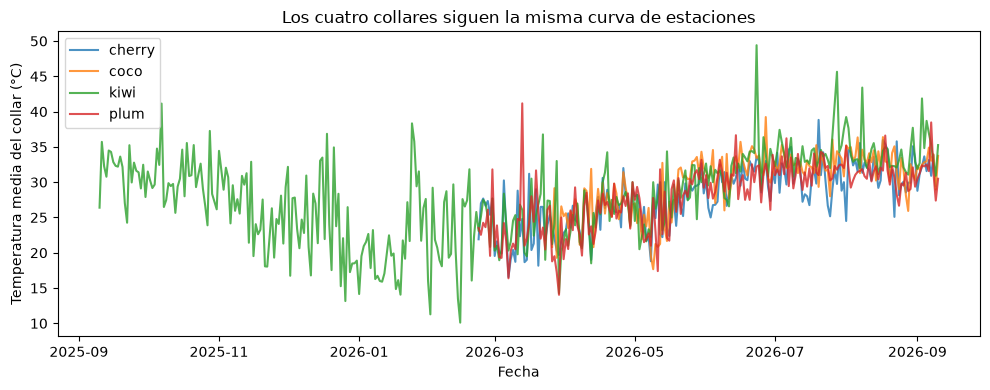

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
for perro in PERROS:
    lecturas = []
    for informe in leer(perro, "hardware_reports"):
        if informe.get("temperature") is not None:
            lecturas.append({"fecha": pd.to_datetime(informe["time"]).date(),
                             "temp": informe["temperature"]})
    por_dia = pd.DataFrame(lecturas).groupby("fecha")["temp"].mean()
    ax.plot(por_dia.index, por_dia.values, label=perro, alpha=0.8)
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura media del collar (°C)")
ax.set_title("Los cuatro collares siguen la misma curva de estaciones")
ax.legend()
plt.tight_layout()
plt.savefig("../img/00_temperatura_dispositivo.png", dpi=150)
plt.show()

Los cuatro siguen la misma curva de estaciones. Pero ¿mide el aire? Si así fuera, de noche marcaría bastante menos que por la tarde, sobre todo en primavera. Se compara la temperatura mediana de las lecturas de noche y de tarde, sin las tomadas con el collar en el cargador:

In [13]:
filas = []
for perro in PERROS:
    for informe in leer(perro, "hardware_reports"):
        if informe.get("temperature") is None or informe.get("charger_connected"):
            continue
        momento = pd.to_datetime(informe["time"]).tz_convert("Europe/Madrid")
        filas.append({"perro": perro, "dia": momento.date(), "mes": momento.month,
                      "hora": momento.hour, "temp": informe["temperature"]})
lecturas = pd.DataFrame(filas)

lecturas["franja"] = "otras horas"
lecturas.loc[lecturas["hora"] <= 6, "franja"] = "noche (0-6 h)"
lecturas.loc[(lecturas["hora"] >= 13) & (lecturas["hora"] <= 18), "franja"] = "tarde (13-18 h)"
lecturas["epoca"] = "otros meses"
lecturas.loc[(lecturas["mes"] >= 4) & (lecturas["mes"] <= 5), "epoca"] = "primavera (abril y mayo)"
lecturas.loc[(lecturas["mes"] >= 7) & (lecturas["mes"] <= 8), "epoca"] = "verano (julio y agosto)"

comparables = lecturas[(lecturas["franja"] != "otras horas") & (lecturas["epoca"] != "otros meses")]
comparables.groupby(["epoca", "franja"])["temp"].median()

epoca                     franja         
primavera (abril y mayo)  noche (0-6 h)      28.0
                          tarde (13-18 h)    29.0
verano (julio y agosto)   noche (0-6 h)      36.0
                          tarde (13-18 h)    33.0
Name: temp, dtype: float64

En primavera, de noche el collar marca casi lo mismo que por la tarde, y en verano marca incluso más, aunque de noche el aire está bastante más fresco que por la tarde. El sensor recoge sobre todo el calor del cuello del perro: sigue las estaciones, pero no es la temperatura del ambiente.

Además, cada collar envía sus lecturas en distinta cantidad y a horas distintas:

In [14]:
por_dia = lecturas.groupby(["perro", "dia"]).size()
pd.DataFrame({
    "lecturas_por_dia_mediana": por_dia.groupby("perro").median(),
    "pct_lecturas_de_noche": lecturas.groupby("perro")["hora"].apply(lambda horas: round(100 * (horas <= 6).mean(), 1)),
})

,lecturas_por_dia_mediana,pct_lecturas_de_noche
perro,,
cherry,9.0,26.8
coco,23.0,10.1
kiwi,16.0,16.3
plum,12.0,8.7


Por eso la media diaria de temperatura de un collar no es directamente comparable con la de otro.

## 7. De JSON a tablas

`data_loader.py` aplica todas las decisiones anteriores y genera los tres datasets del proyecto. Después se comprueba que cumplen lo esperado.

In [15]:
dimensiones = data_loader.guardar_datasets(CRUDOS, PERROS, "../data_sample")
dimensiones

{'diario_perros': (898, 24),
 'ladridos_30min': (27312, 4),
 'actividad_horaria': (21552, 9)}

In [16]:
diario = pd.read_csv("../data_sample/diario_perros.csv", parse_dates=["fecha"])
horaria = pd.read_csv("../data_sample/actividad_horaria.csv")
columnas_min = ["min_reposo", "min_calma", "min_activo", "min_intenso", "min_sin_datos", "min_otros"]

print("Filas duplicadas (mismo perro y día):", diario.duplicated(subset=["perro", "fecha"]).sum(),
      "-> debe ser 0")
suma_dia = diario[columnas_min].sum(axis=1)
print("Minutos por día: mínimo", round(suma_dia.min(), 6), "| máximo", round(suma_dia.max(), 6),
      "-> debe ser 1440")
suma_hora = horaria[columnas_min].sum(axis=1)
print("Minutos por hora: mínimo", round(suma_hora.min(), 6), "| máximo", round(suma_hora.max(), 6),
      "-> debe ser 60")
print("Días de kiwi con dato de ladridos:", diario[diario["perro"] == "kiwi"]["ladridos_total"].notna().sum(),
      "-> debe ser 0")
diario.head()

Filas duplicadas (mismo perro y día): 0 -> debe ser 0
Minutos por día: mínimo 1440.0 | máximo 1440.0 -> debe ser 1440
Minutos por hora: mínimo 60.0 | máximo 60.0 -> debe ser 60
Días de kiwi con dato de ladridos: 0 -> debe ser 0


,perro,fecha,min_reposo,min_calma,min_activo,min_intenso,min_sin_datos,min_otros,ladridos_total,ladridos_franjas,...,fc_n,fr_media,fr_min,fr_max,fr_n,temp_disp_media,temp_disp_max,dia_semana,es_finde,mes
0,cherry,2026-02-22,240.183333,6.416667,7.950000,0.0,1185.450000,0.0,6.0,2.0,...,22.0,9.471429,7.0,14.0,70.0,21.909091,28,Sunday,True,2
1,cherry,2026-02-23,888.233333,85.266667,117.700000,0.0,348.800000,0.0,149.0,11.0,...,76.0,8.460938,5.0,20.0,128.0,27.000000,35,Monday,False,2
2,cherry,2026-02-24,933.016667,67.616667,108.600000,0.0,330.766667,0.0,289.0,15.0,...,71.0,7.847826,5.0,14.0,138.0,27.684211,32,Tuesday,False,2
3,cherry,2026-02-25,1014.400000,50.433333,87.466667,0.0,287.700000,0.0,565.0,19.0,...,86.0,7.922619,4.0,16.0,168.0,26.666667,35,Wednesday,False,2
4,cherry,2026-02-26,901.866667,79.583333,116.683333,0.0,341.866667,0.0,351.0,10.0,...,51.0,7.909677,5.0,16.0,155.0,27.333333,36,Thursday,False,2


## 8. Diccionario de datos

### `src/data_sample/diario_perros.csv` — una fila por perro y día

| Columna | Tipo | Clase | Descripción | Origen |
|---|---|---|---|---|
| `perro` | texto | categórica (4 valores) | nombre del perro; **target del modelo** | carpeta del export |
| `fecha` | fecha | fecha | día, en hora local del collar | `activity_data` |
| `min_reposo` | decimal | numérica continua | minutos del día en categoría 6 | `activity_data` |
| `min_calma` | decimal | numérica continua | minutos en categoría 0 | `activity_data` |
| `min_activo` | decimal | numérica continua | minutos en categoría 1 | `activity_data` |
| `min_intenso` | decimal | numérica continua | minutos en categoría 7, solo en tramos de hasta 2 h (§4.1) | `activity_data` |
| `min_sin_datos` | decimal | numérica continua | minutos sin medir: categorías -1 y `None`, más los bloques de categoría 7 de más de 2 h. **Indica la calidad del día** | `activity_data` |
| `min_otros` | decimal | numérica continua | minutos en categoría 5 | `activity_data` |
| `ladridos_total` | decimal | numérica discreta | ladridos del día; **vacío en kiwi** (sin sensor) | `barks` |
| `ladridos_franjas` | decimal | numérica discreta | franjas de 30 min con algún ladrido (0 a 48) | `barks` |
| `ladridos_max_30min` | decimal | numérica discreta | máximo de ladridos en una franja | `barks` |
| `fc_media`, `fc_min`, `fc_max` | decimal | numérica continua | frecuencia cardíaca en reposo (lpm) | `resting_heart_rates` |
| `fc_n` | decimal | numérica discreta | nº de muestras de FC del día | `resting_heart_rates` |
| `fr_media`, `fr_min`, `fr_max` | decimal | numérica continua | frecuencia respiratoria en reposo (rpm) | `resting_respiratory_rates` |
| `fr_n` | decimal | numérica discreta | nº de muestras de FR del día | `resting_respiratory_rates` |
| `temp_disp_media` | decimal | numérica continua | temperatura media del collar (°C) | `hardware_reports` |
| `temp_disp_max` | entero | numérica continua | temperatura máxima del collar (°C) | `hardware_reports` |
| `dia_semana` | texto | categórica (7 valores) | día de la semana, en inglés | `fecha` |
| `es_finde` | booleana | binaria | sábado o domingo | `fecha` |
| `mes` | entero | categórica (1 a 12) | mes; se trata como categoría, no como cantidad | `fecha` |

### `src/data_sample/ladridos_30min.csv` — una fila por perro, día y franja de 30 minutos

| Columna | Tipo | Clase | Descripción |
|---|---|---|---|
| `perro` | texto | categórica | nombre del perro (kiwi no aparece: no tiene sensor) |
| `fecha` | fecha | fecha | día |
| `franja_30min` | entero | categórica (0 a 47) | franja del día: 0 es 00:00-00:30 y 47 es 23:30-24:00 |
| `ladridos` | entero | numérica discreta | ladridos en esa franja (`null` en el JSON pasa a 0) |

### `src/data_sample/actividad_horaria.csv` — una fila por perro, día y hora

| Columna | Tipo | Clase | Descripción |
|---|---|---|---|
| `perro`, `fecha` | texto, fecha | — | como en el dataset diario |
| `hora` | entero | categórica (0 a 23) | hora local del día |
| `min_reposo` … `min_otros` | decimal | numérica continua | minutos de esa hora en cada categoría; suman 60 por fila |

**Notas**

- Algunos conteos son decimales porque los nulos (kiwi, días sin muestras) obligan a pandas a usar `float`.
- Las columnas `min_*` suman 1.440 en cada día. Por eso `main.ipynb` compara porcentajes del tiempo medido y no minutos (`main`, 3.4).

## 9. Conclusiones

1. Los cuatro exports tienen la misma estructura y los tramos de actividad cubren el 100 % de cada día.
2. **Kiwi no tiene sensor de ladridos**: sus nulos de ladridos son estructurales.
3. Las categorías de actividad se han interpretado por la hora en que aparecen: 6 reposo, 0 calma, 1 activo, 7 intenso, -1 y `None` sin datos. **Los bloques de categoría 7 de más de 2 horas no son actividad real** y se cuentan como sin datos.
4. Cada perro tiene un histórico de distinta longitud. `main.ipynb` trabaja con los tres perros que llevan el mismo modelo de collar y usa solo la ventana con datos de los tres.
5. Hay días con pocas muestras vitales, y la cantidad de muestras depende del collar: `fc_n` y `fr_n` no describen el comportamiento.
6. La temperatura del collar sigue la curva de las estaciones, pero recoge sobre todo el calor del perro, y cada collar envía sus lecturas a horas distintas: no es la temperatura del ambiente ni es comparable entre perros.
7. Ningún dataset derivado contiene coordenadas.

**Siguiente paso →** `main.ipynb`.